In [1]:
import os
import cv2
import torch
import joblib
import numpy as np
import pandas as pd

from PIL import Image
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
class_names = [
    "Healthy",
    "Early Deficiency",
    "Critical Deficiency"
]


In [3]:
features = [
    "N", "P", "K",
    "ph",
    "soil_moisture",
    "temperature",
    "humidity",
    "rainfall",
    "sunlight_exposure"
]

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# 🔥 For recommendation (train data)
train_df = pd.read_csv("train_data.csv")

# 🔥 For evaluation (IMPORTANT)
test_df = pd.read_csv("test_data.csv")

In [6]:
class DSEE(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.h = nn.Conv2d(in_channels, in_channels, (1,3), padding=(0,1))
        self.v = nn.Conv2d(in_channels, in_channels, (3,1), padding=(1,0))
        self.d1 = nn.Conv2d(in_channels, in_channels, 3, padding=1)
        self.d2 = nn.Conv2d(in_channels, in_channels, 3, padding=1)
        self.r = nn.Conv2d(in_channels, in_channels, 3, padding=1)

        self.fusion = nn.Conv2d(in_channels*5, in_channels, 1)
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = torch.cat([
            self.h(x),
            self.v(x),
            self.d1(x),
            self.d2(x),
            self.r(x)
        ], dim=1)

        out = self.fusion(out)
        out = self.bn(out)
        return self.relu(out)


In [7]:
class ImageModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.efficientnet_b3(weights=None)
        self.features = self.backbone.features

        self.dsee = DSEE(1536)
        self.pool = nn.AdaptiveAvgPool2d(1)

        # 🔥 EXACT SAME AS TRAINING
        self.classifier = nn.Sequential(
            nn.Linear(1536, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        f = self.features(x)
        e = self.dsee(f)

        fused = f + e
        pooled = self.pool(fused).view(fused.size(0), -1)

        return self.classifier(pooled)

In [8]:
image_model = ImageModel()

state_dict = torch.load("image_model.pth", map_location=device)

fixed_state_dict = {}

for k, v in state_dict.items():

    new_key = k

    # 🔥 FIX DSEE naming mismatch
    new_key = new_key.replace("h_conv", "h")
    new_key = new_key.replace("v_conv", "v")
    new_key = new_key.replace("d1_conv", "d1")
    new_key = new_key.replace("d2_conv", "d2")
    new_key = new_key.replace("radial_conv", "r")

    # ⚠️ DO NOT REMOVE backbone
    # (keep backbone.features as is)

    fixed_state_dict[new_key] = v

# ✅ Load with relaxed strict (safe)
image_model.load_state_dict(fixed_state_dict, strict=False)

image_model.to(device)
image_model.eval()

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [9]:
scaler = joblib.load("rf_scaler.pkl")
rf_model = joblib.load("rf_metadata_model.pkl")
rf_classes = rf_model.classes_


In [10]:
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [11]:
def image_prediction(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print(f"⚠️ Skipping invalid image: {image_path}")
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img)

    img_tensor = transform(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = image_model(img_tensor)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]

    return probs

In [12]:
def metadata_prediction(metadata_dict):
    df = pd.DataFrame([metadata_dict])
    scaled = scaler.transform(df[features])

    probs = rf_model.predict_proba(scaled)[0]

    ordered = np.zeros(len(class_names))
    for i, cls in enumerate(rf_classes):
        ordered[class_names.index(cls)] = probs[i]

    return ordered


In [13]:
def dynamic_fusion(img_prob, meta_prob):
    return 0.7 * img_prob + 0.3 * meta_prob

In [14]:
def get_best_recommendation(metadata_dict, predicted_class):

    class_data = train_df[train_df["Label"] == predicted_class]

    X_scaled = scaler.transform(class_data[features])
    y = class_data["Recommendation"].values

    input_scaled = scaler.transform(pd.DataFrame([metadata_dict])[features])

    distances = np.linalg.norm(X_scaled - input_scaled, axis=1)
    top_k = np.argsort(distances)[:5]

    return y[np.random.choice(top_k)]

In [27]:
def multimodal_predict(image_path, metadata_dict):

    img_prob = image_prediction(image_path)
    if img_prob is None:
        return

    meta_prob = metadata_prediction(metadata_dict)

    final_prob = dynamic_fusion(img_prob, meta_prob)

    final_class = class_names[np.argmax(final_prob)]
    confidence = np.max(final_prob) * 100

    recommendation = get_best_recommendation(metadata_dict, final_class)

    print("\n===== Crop Health Diagnosis =====")
    print("\nImage Probabilities:", np.round(img_prob, 4))
    print("Metadata Probabilities:", np.round(meta_prob, 4))
    print("Fusion Probabilities:", np.round(final_prob, 4))

    print("\nPredicted Class:", final_class)
    print(f"Confidence Score: {confidence:.2f}%")

    print("\nRecommendation:\n", recommendation)


In [39]:
def evaluate_multimodal():

    test_folder = "test"

    all_preds = []
    all_labels = []

    index = 0

    for cls in class_names:
        path = os.path.join(test_folder, cls, "images")

        if not os.path.exists(path):
            continue

        for img_file in os.listdir(path):

            if not img_file.lower().endswith((".jpg",".png",".jpeg")):
                continue

            if index >= len(test_df):
                break

            img_path = os.path.join(path, img_file)
            metadata = test_df.iloc[index][features].to_dict()

            img_prob = image_prediction(img_path)
            if img_prob is None:
                continue

            meta_prob = metadata_prediction(metadata)
            final_prob = dynamic_fusion(img_prob, meta_prob)

            all_preds.append(np.argmax(final_prob))
            all_labels.append(class_names.index(cls))

            index += 1

    print("\n🔥 Accuracy:", accuracy_score(all_labels, all_preds))
    print("\nClassification Report:\n",
          classification_report(all_labels, all_preds, target_names=class_names))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.show()



In [40]:
image_path = "test/Early Deficiency/images/Early-Deficiency-58-_90_jpg.rf.d4febfd2040ae5217b7c41ef51ee2484.jpg"
metadata ={
"N": 52,
"P": 44,
"K": 43,
"ph": 5.0,
"soil_moisture": 14.3,
"temperature": 20.1,
"humidity": 36.2,
"rainfall": 45.0,
"sunlight_exposure": 7.2
}
multimodal_predict(image_path, metadata)


===== Crop Health Diagnosis =====

Image Probabilities: [1.000e-04 9.994e-01 5.000e-04]
Metadata Probabilities: [0.0131 0.5707 0.4161]
Fusion Probabilities: [0.004  0.8708 0.1252]

Predicted Class: Early Deficiency
Confidence Score: 87.08%

Recommendation:
 Attention: Early signs of deficiency detected. Nitrogen is relatively low. Apply nitrogen-rich fertilizers like urea or compost. Potassium is insufficient. Add potash fertilizers to improve plant strength. Soil moisture is low. Ensure regular irrigation and consider mulching. Soil pH is below optimal range. Apply lime to balance soil acidity.



🔥 Accuracy: 0.9741379310344828

Classification Report:
                      precision    recall  f1-score   support

            Healthy       1.00      1.00      1.00        43
   Early Deficiency       0.93      1.00      0.96        38
Critical Deficiency       1.00      0.91      0.96        35

           accuracy                           0.97       116
          macro avg       0.98      0.97      0.97       116
       weighted avg       0.98      0.97      0.97       116



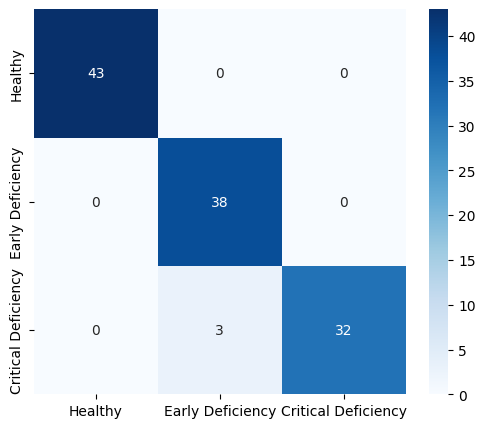

In [41]:
evaluate_multimodal()